# Task 3 Reportes

## Integrantes
* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007

### Tendencia de disparidad

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd


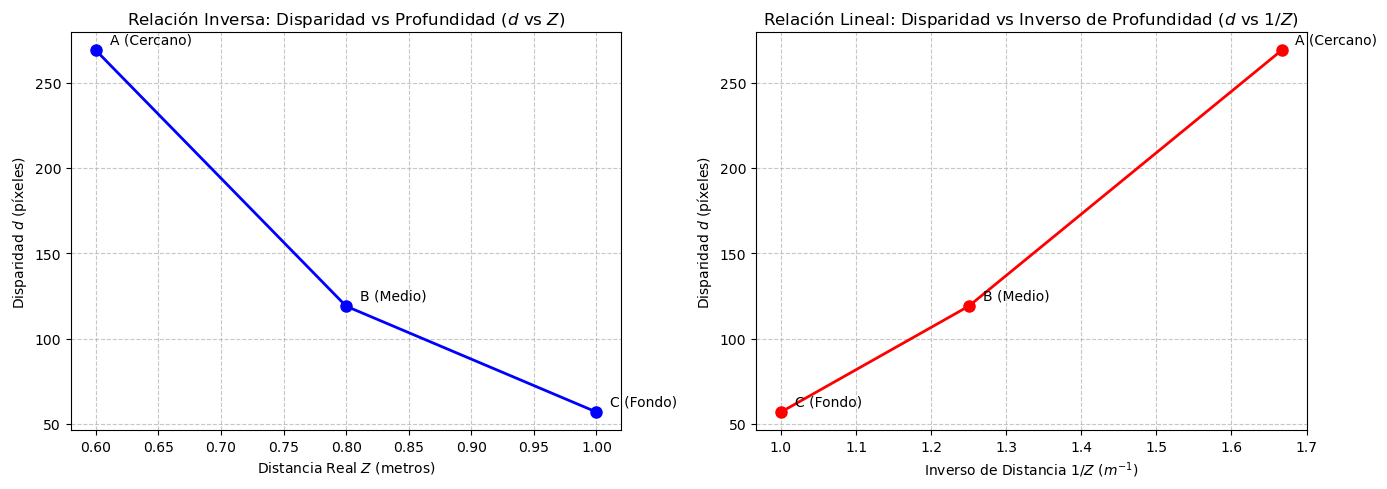

In [ ]:


# datos obtenidos en el Task 2
data = {
    "Objeto": ["A (Cercano)", "B (Medio)", "C (Fondo)"],
    "Distancia_Real_m": [0.6, 0.8, 1.0],       # Z
    "Disparidad_px": [268.93, 118.95, 56.89]   # d
}

df = pd.DataFrame(data)

df["Inv_Distancia"] = 1 / df["Distancia_Real_m"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(df["Distancia_Real_m"], df["Disparidad_px"], 'bo-', linewidth=2, markersize=8)
plt.title("Relación Inversa: Disparidad vs Profundidad ($d$ vs $Z$)", fontsize=12)
plt.xlabel("Distancia Real $Z$ (metros)", fontsize=10)
plt.ylabel("Disparidad $d$ (píxeles)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
for i, txt in enumerate(df["Objeto"]):
    plt.annotate(txt, (df["Distancia_Real_m"][i], df["Disparidad_px"][i]), xytext=(10,5), textcoords='offset points')

plt.subplot(1, 2, 2)
plt.plot(df["Inv_Distancia"], df["Disparidad_px"], 'ro-', linewidth=2, markersize=8)
plt.title("Relación Lineal: Disparidad vs Inverso de Profundidad ($d$ vs $1/Z$)", fontsize=12)
plt.xlabel("Inverso de Distancia $1/Z$ ($m^{-1}$)", fontsize=10)
plt.ylabel("Disparidad $d$ (píxeles)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
for i, txt in enumerate(df["Objeto"]):
    plt.annotate(txt, (df["Inv_Distancia"][i], df["Disparidad_px"][i]), xytext=(10,5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Modelos Matemáticos

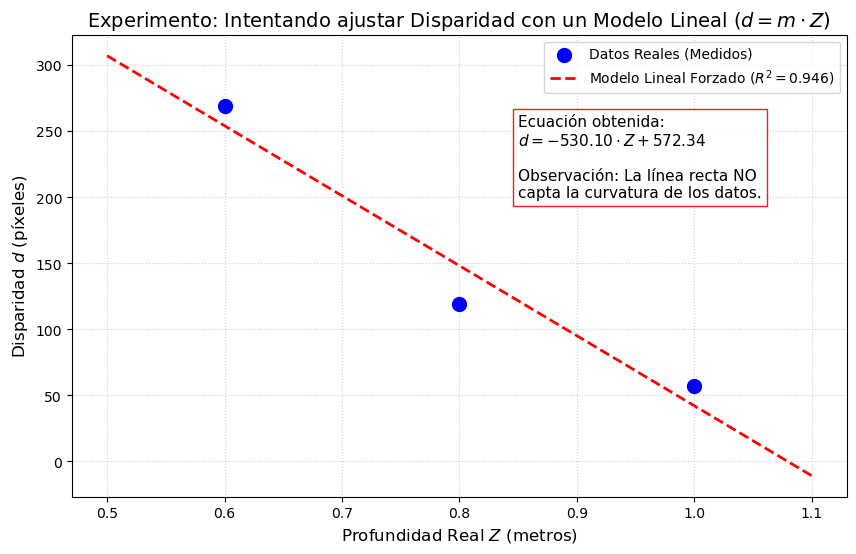

In [ ]:

def experimento_modelo_lineal():
    Z = np.array([0.6, 0.8, 1.0])      
    d = np.array([268.93, 118.95, 56.89]) 

    # Ajuste Lineal 
    coeficientes = np.polyfit(Z, d, 1)
    pendiente = coeficientes[0]
    intercepto = coeficientes[1]
    
    d_predicha = np.polyval(coeficientes, Z)
    
    r2 = r2_score(d, d_predicha)

    plt.figure(figsize=(10, 6))
    
    # Puntos reales
    plt.scatter(Z, d, color='blue', s=100, label='Datos Reales (Medidos)', zorder=5)
    
    z_range = np.linspace(0.5, 1.1, 100)
    d_model = pendiente * z_range + intercepto
    plt.plot(z_range, d_model, 'r--', linewidth=2, label=f'Modelo Lineal Forzado ($R^2={r2:.3f}$)')

    plt.title("Experimento: Intentando ajustar Disparidad con un Modelo Lineal ($d = m \\cdot Z$)", fontsize=14)
    plt.xlabel("Profundidad Real $Z$ (metros)", fontsize=12)
    plt.ylabel("Disparidad $d$ (píxeles)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    texto_error = (f"Ecuación obtenida:\n$d = {pendiente:.2f} \\cdot Z + {intercepto:.2f}$\n\n"
                   f"Observación: La línea recta NO\ncapta la curvatura de los datos.")
    plt.text(0.85, 200, texto_error, fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='red'))

    plt.show()

  

if __name__ == "__main__":
    experimento_modelo_lineal()

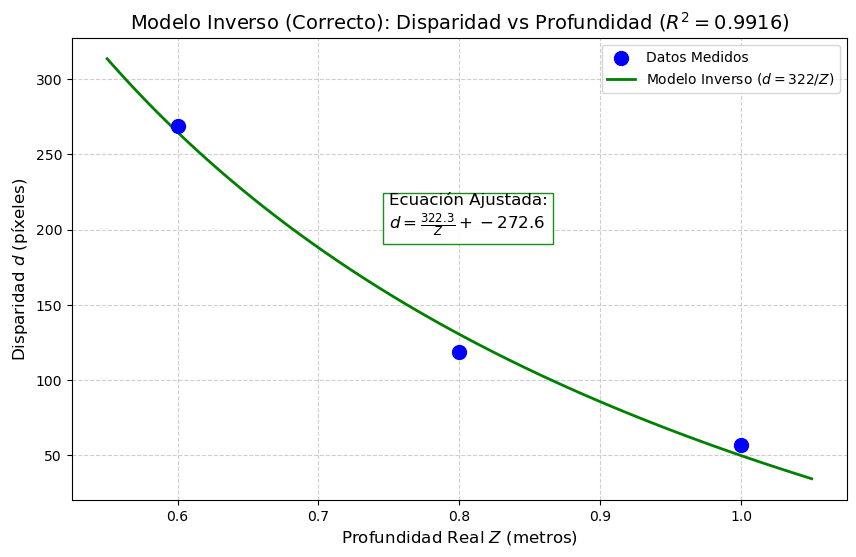

In [ ]:


def modelo_inverso_correcto():
    inv_Z = 1 / Z
    
    coeficientes = np.polyfit(inv_Z, d, 1)
    k = coeficientes[0] 
    c = coeficientes[1]  

    Z_model = np.linspace(0.55, 1.05, 100)
    d_model = (k / Z_model) + c

    d_predicha = (k / Z) + c
    r2 = r2_score(d, d_predicha)

    plt.figure(figsize=(10, 6))
    
    plt.scatter(Z, d, color='blue', s=100, label='Datos Medidos', zorder=5)
    
    plt.plot(Z_model, d_model, color='green', linewidth=2, label=f'Modelo Inverso ($d = {k:.0f}/Z$)')

    plt.title(f"Modelo Inverso (Correcto): Disparidad vs Profundidad ($R^2 = {r2:.4f}$)", fontsize=14)
    plt.xlabel("Profundidad Real $Z$ (metros)", fontsize=12)
    plt.ylabel("Disparidad $d$ (píxeles)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.text(0.75, 200, f"Ecuación Ajustada:\n$d = \\frac{{{k:.1f}}}{{Z}} + {c:.1f}$", 
             fontsize=12, bbox=dict(facecolor='white', edgecolor='green', alpha=0.9))

    plt.show()

   

if __name__ == "__main__":
    modelo_inverso_correcto()